### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [74]:
import tensorflow as tf
from tensorflow.keras import layers, Model

### Step 2: Load Data

In [3]:
df = pd.read_csv('./data/city_day.csv')

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.shape

(29531, 16)

In [25]:
df.sample(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
17771,Jorapokhar,2017-06-29,NaN,189.13,NaN,NaN,NaN,NaN,0.19,2.98,35.52,NaN,NaN,NaN,NaN,NaN
27284,Thiruvananthapuram,2018-05-09,23.21,42.75,2.90,13.19,9.36,2.66,1.01,5.79,34.32,NaN,NaN,NaN,67.0,Satisfactory
2715,Amaravati,2019-07-10,13.03,29.59,5.45,25.64,18.15,2.13,0.51,20.09,32.10,0.15,1.14,0.11,75.0,Satisfactory
7303,Brajrajnagar,2019-11-18,76.72,171.91,19.21,18.41,16.67,48.33,0.49,13.49,5.87,0.00,NaN,NaN,184.0,Moderate
28768,Visakhapatnam,2018-05-31,34.18,107.24,2.87,20.48,13.24,12.80,0.43,3.51,42.74,3.19,6.31,1.71,103.0,Moderate


### Step 3: Exploaring Data

Basic Info

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,29531,2018-05-14 05:40:15.807118080,2015-01-01 00:00:00,2017-04-16 00:00:00,2018-08-05 00:00:00,2019-09-03 00:00:00,2020-07-01 00:00:00,NaN
PM2.5,24933.0,67.450578,0.04,28.82,48.57,80.59,949.99,64.661449
PM10,18391.0,118.127103,0.01,56.255,95.68,149.745,1000.0,90.60511
NO,25949.0,17.57473,0.02,5.63,9.89,19.95,390.68,22.785846
NO2,25946.0,28.560659,0.01,11.75,21.69,37.62,362.21,24.474746
NOx,25346.0,32.309123,0.0,12.82,23.52,40.1275,467.63,31.646011
NH3,19203.0,23.483476,0.01,8.58,15.85,30.02,352.89,25.684275
CO,27472.0,2.248598,0.0,0.51,0.89,1.45,175.81,6.962884
SO2,25677.0,14.531977,0.01,5.67,9.16,15.22,193.86,18.133775
O3,25509.0,34.49143,0.01,18.86,30.84,45.57,257.73,21.694928


In [13]:
feature_info = pd.DataFrame(
    {'null': df.isnull().sum(), 'unique': df.nunique(), 'type': df.dtypes}
)

In [14]:
feature_info

,null,unique,type
City,0,26,object
Date,0,2009,datetime64[ns]
PM2.5,4598,11716,float64
PM10,11140,12571,float64
NO,3582,5776,float64
NO2,3585,7404,float64
NOx,4185,8156,float64
NH3,10328,5922,float64
CO,2059,1779,float64
SO2,3854,4761,float64


Target Distribution

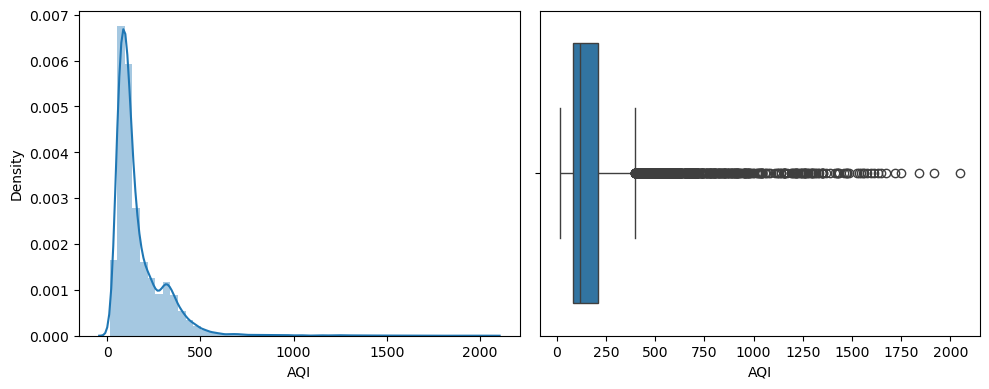

In [17]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['AQI'])
plt.subplot(1, 2, 2)
sns.boxplot(df['AQI'], orient='h')
plt.tight_layout()

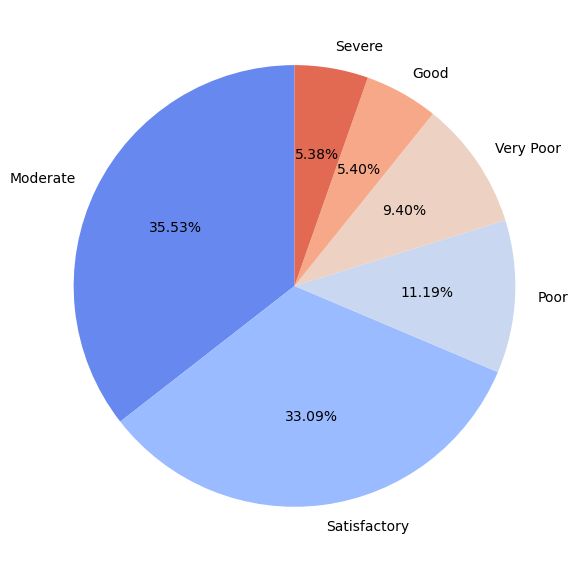

In [34]:
temp = df['AQI_Bucket'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    temp,
    labels=temp.index,
    autopct='%.2f%%',
    colors=sns.color_palette('coolwarm', len(temp)),
    startangle=90
)
plt.tight_layout()

Object Distribution

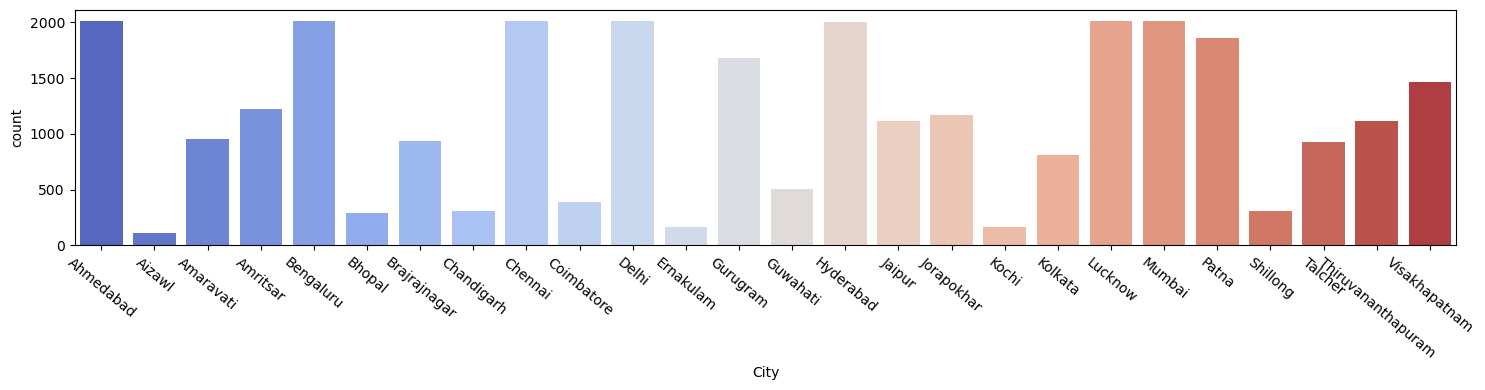

In [24]:
plt.figure(figsize=(15, 4))
sns.countplot(x='City', data=df, palette='coolwarm')
plt.xticks(rotation=-40)
plt.tight_layout()

Float Distribution

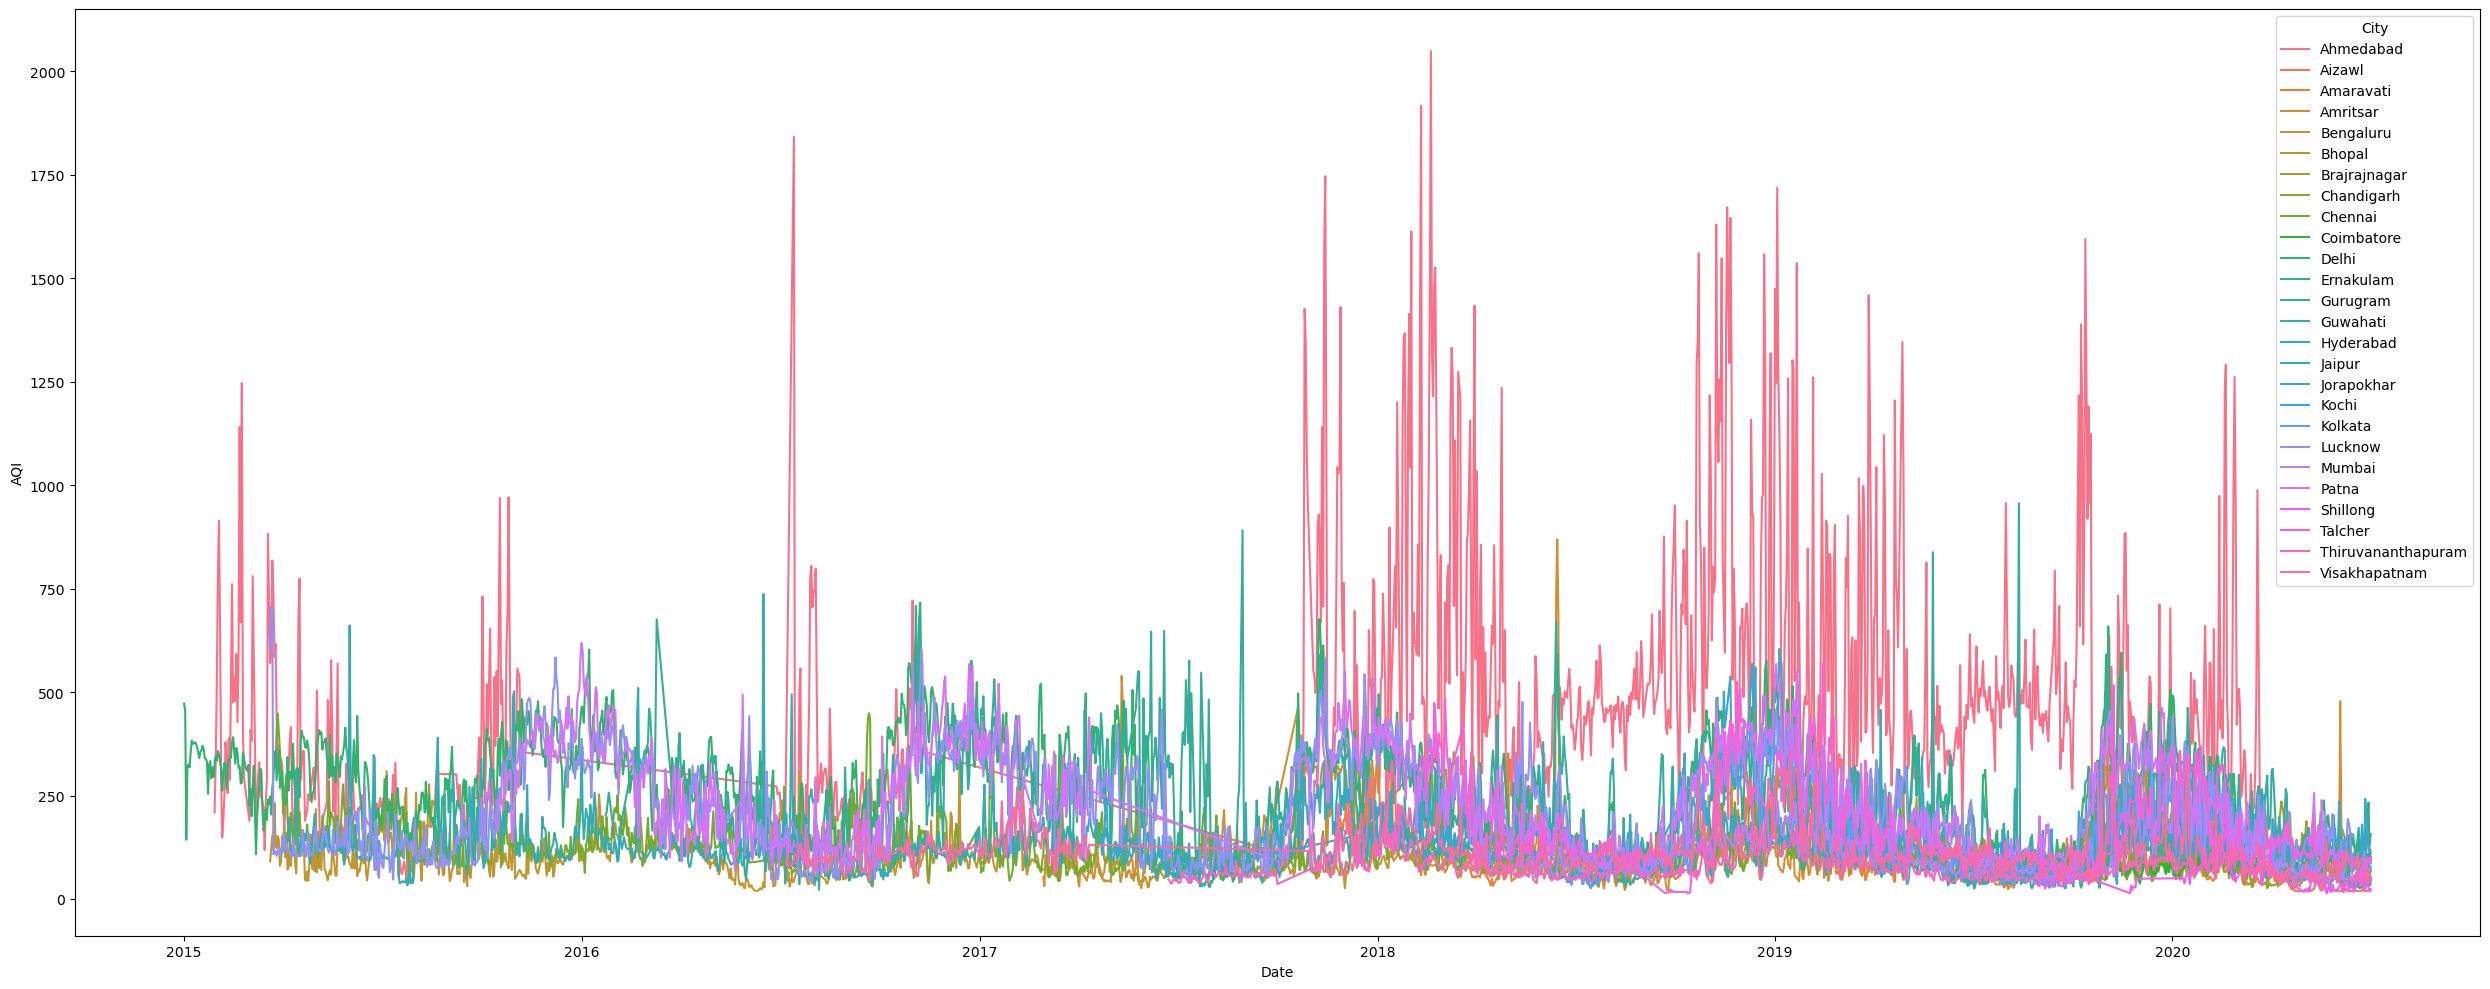

In [46]:
plt.figure(figsize=(25, 10))
sns.lineplot(x='Date', y='AQI', data=df, hue='City')
plt.tight_layout()

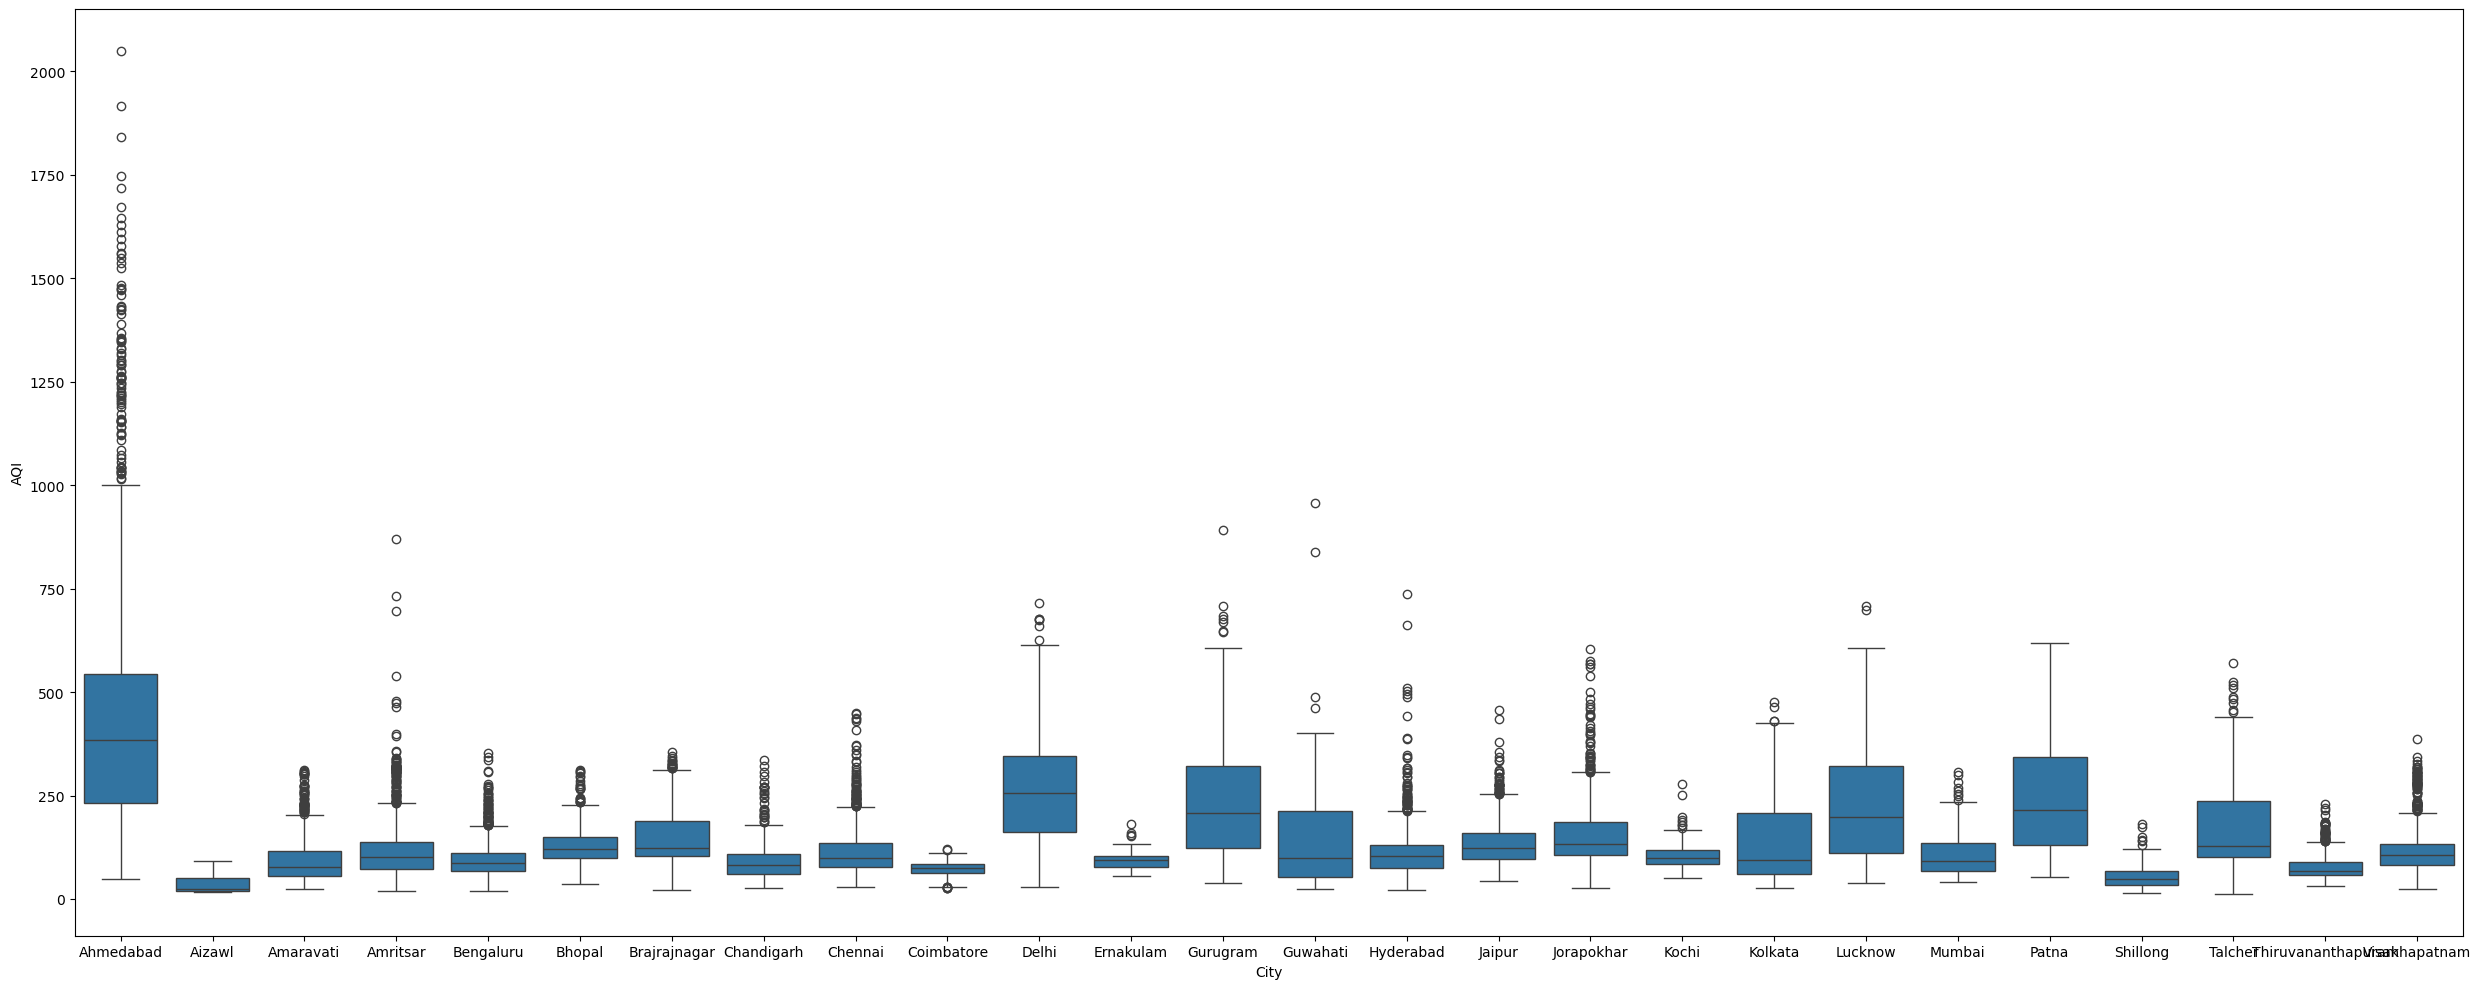

In [47]:
plt.figure(figsize=(25, 10))
sns.boxplot(x='City', y='AQI', data=df)
plt.tight_layout()

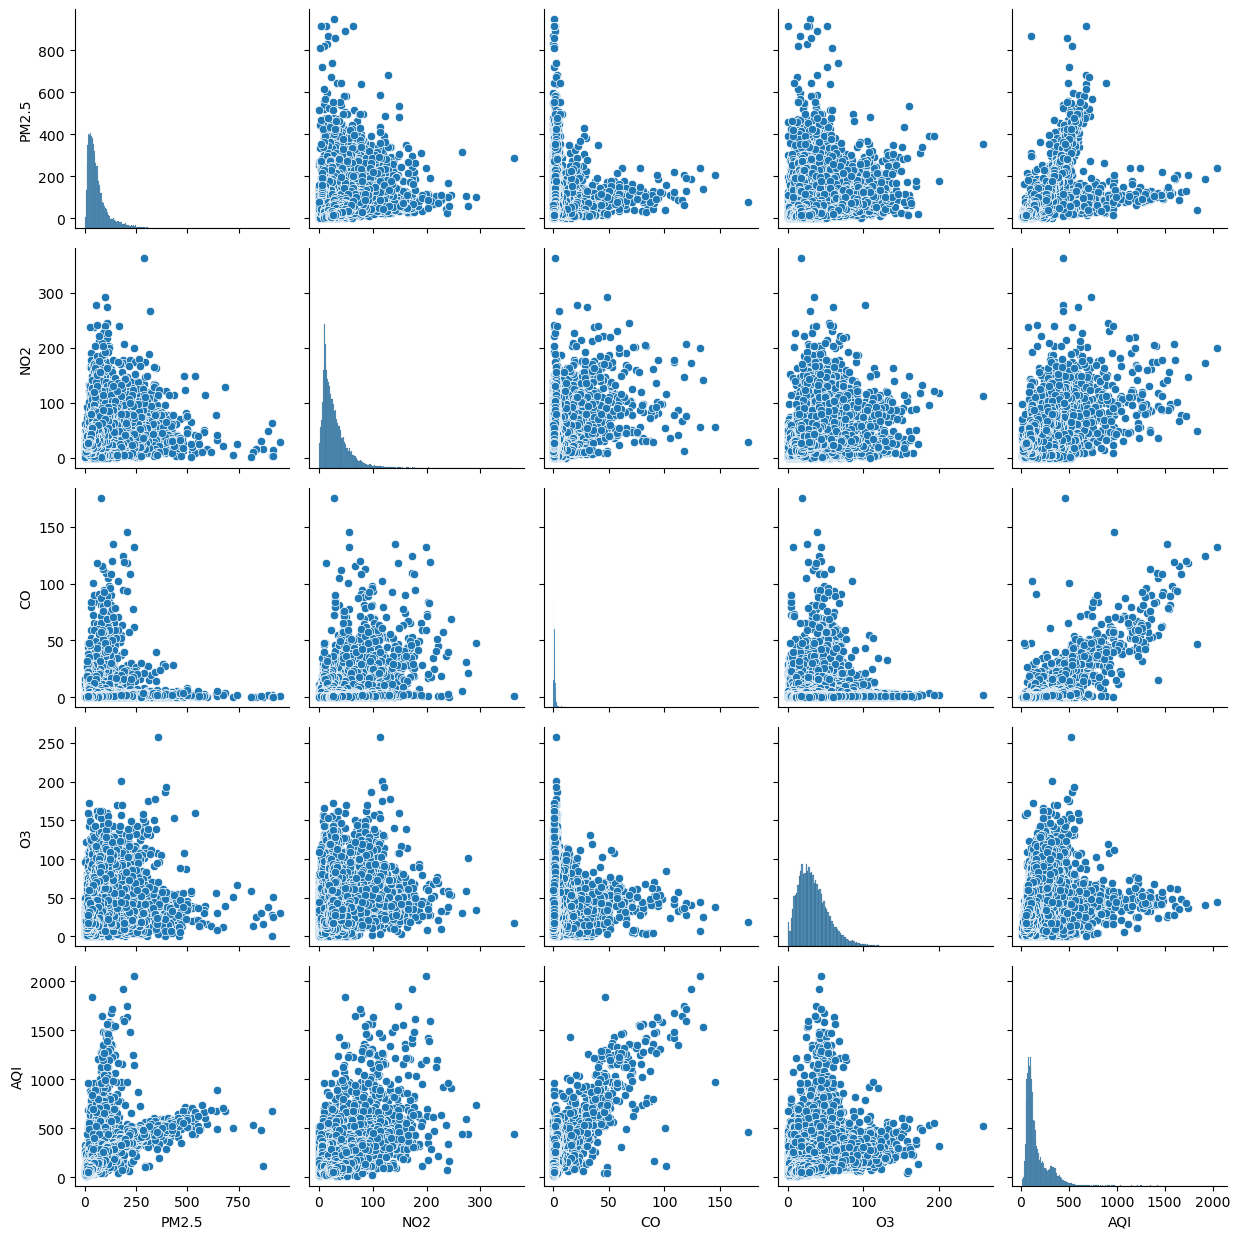

In [51]:
sns.pairplot(data=df[['PM2.5', 'NO2', 'CO', 'O3', 'AQI']], dropna=True)
plt.tight_layout()

### Step 4: Feature Engineering

Handling Missing Value

In [53]:
df.dropna(axis=0, inplace=True)

Feature Encoding

In [56]:
le = LabelEncoder()

In [57]:
df['AQI_Bucket'] = le.fit_transform(df['AQI_Bucket'])

Heat Map

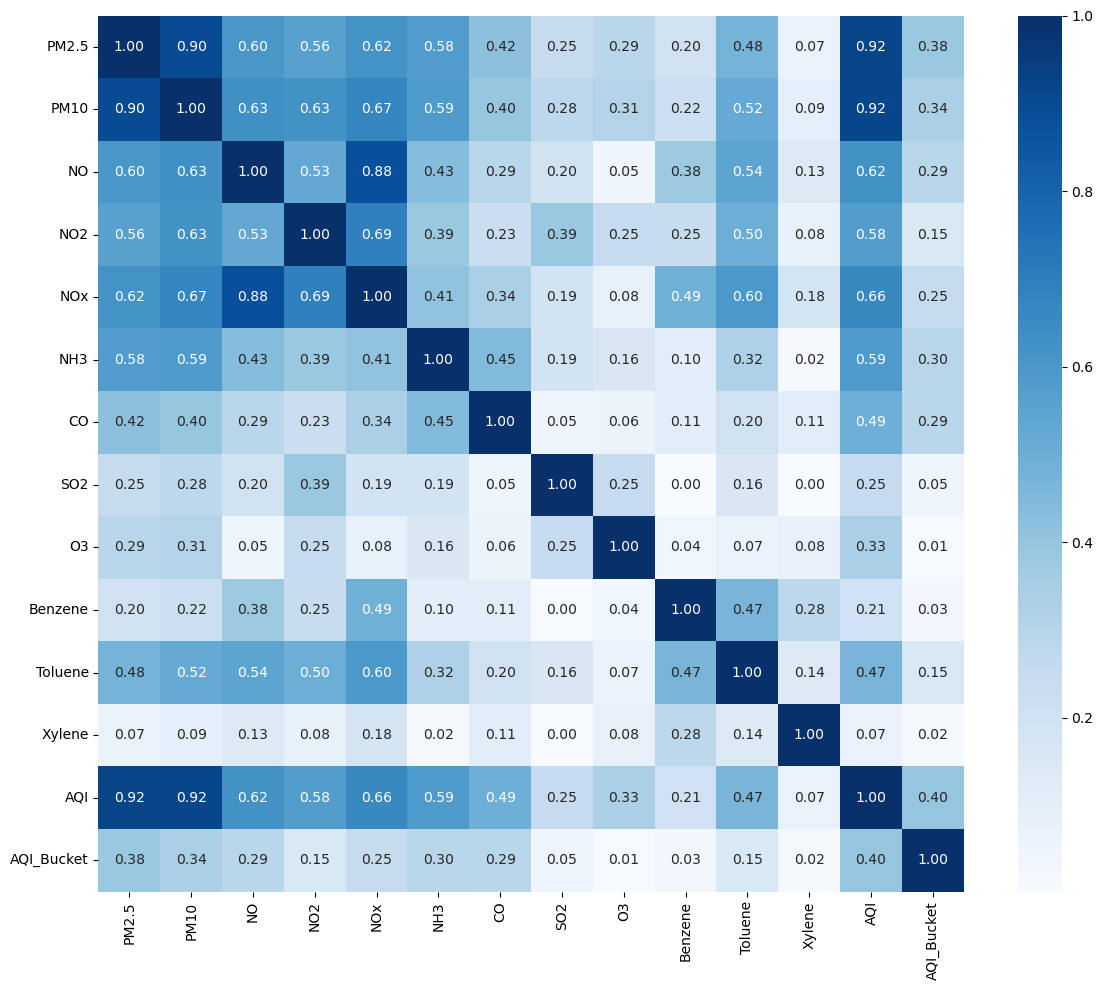

In [60]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.select_dtypes(np.number).corr().abs(),
    annot=True,
    fmt='.2f',
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

Select Featuers

In [70]:
features = df.drop(['City', 'Date', 'AQI', 'AQI_Bucket'], axis=1)
target = df['AQI']

Split Data

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

Normalization

In [72]:
scaler = StandardScaler()

In [73]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

Building Model

In [126]:
inputs = layers.Input(shape=(12,))
x = layers.Dense(64, activation='relu', kernel_initializer='uniform')(inputs)
x = layers.Dense(32, activation='relu', kernel_initializer='uniform')(x)
outputs = layers.Dense(1)(x)

In [127]:
model = Model(inputs, outputs)

In [128]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 12)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 64)                  │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [129]:
model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

Training Model

In [130]:
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2)

Epoch 1/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 24983.0781 - val_loss: 16023.2598
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7679.2798 - val_loss: 4964.4004
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3849.4568 - val_loss: 3247.8057
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2468.7205 - val_loss: 1959.8143
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1549.4683 - val_loss: 1177.6080
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1082.5721 - val_loss: 901.1393
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 903.8532 - val_loss: 814.8368
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 850.2132 - val_loss: 778.8521
Epoch 9/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 822.4651 - val_loss: 759.8586
Epoch 10/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 811.7595 - val_loss: 748.7652
Epoch 11/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 803.0400 - val

Evaluating Model

In [131]:
y_pred = model.predict(X_test)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [132]:
r2_score = metrics.r2_score(y_test, y_pred)
mse_score = metrics.mean_squared_error(y_test, y_pred)

In [133]:
print(f'R2 on Test Data: {r2_score:.3f}')
print(f'Mean Squared Error on Test Data: {mse_score:.3f}')

R2 on Test Data: 0.946
Mean Squared Error on Test Data: 449.505


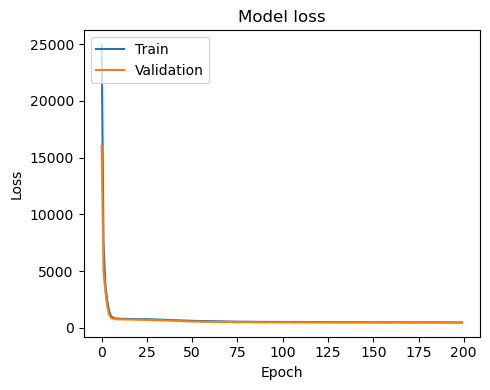

In [134]:
plt.figure(figsize=(5, 4))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()

### Step 7: Predicting Model

In [135]:
user_input = pd.DataFrame({
    'PM2.5': [81],
    'PM10': [124],
    'NO': [1.44],
    'NO2': [20],
    'NOx': [12],
    'NH3': [10],
    'CO': [0.1],
    'SO2': [15],
    'O3': [127],
    'Benzene': [0.20],
    'Toluene': [6],
    'Xylene': [0.06]
})

In [136]:
user_input_scaled = scaler.transform(user_input)

In [137]:
user_pred = model.predict(user_input_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [139]:
print(f"Predicted AQI: {user_pred[0][0]}")

Predicted AQI: 200.34829711914062
